# TCR-Epitope Baseline Results

Presentation-ready notebook for the classical ML baseline before the GNN stage. It highlights the embedding pipeline, the MLflow results, and a small set of figures that are useful on slides.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display
import mlflow

MLFLOW_URI = "sqlite:////home/helen/projectsZHAW/VT1/iggytop/outputs/mlflow.db"
EXPERIMENT_NAME = "tcr_epitope_baselines"
MODEL_NAMES = ["RandomForest_v3", "LogisticRegression_v3"]
MODEL_LABELS = {
    "RandomForest_v3": "Random Forest v3",
    "LogisticRegression_v3": "Logistic Regression v3",
}
MODEL_STYLE = {
    "RandomForest_v3": {"color": "#1f77b4", "marker": "o"},
    "LogisticRegression_v3": {"color": "#d62728", "marker": "s"},
}
METRICS = ["auc", "pr_auc", "accuracy", "precision", "recall"]

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 11,
})

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME], output_format="pandas")
runs = runs[runs["tags.mlflow.runName"].isin(MODEL_NAMES)].copy()
runs["start_time"] = pd.to_datetime(runs["start_time"], errors="coerce")

if runs.empty:
    raise ValueError("No baseline runs were found. Check the MLflow database path and experiment name.")

def metric_col(split, metric):
    return f"metrics.{split}_{metric}"

def numeric_series(df, column):
    if column not in df.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(df[column], errors="coerce").dropna()

def aggregate_metrics(df):
    rows = []
    for run_name in MODEL_NAMES:
        group = df[df["tags.mlflow.runName"] == run_name].copy()
        row = {
            "run_name": run_name,
            "model": MODEL_LABELS[run_name],
            "n_runs": len(group),
        }
        for split in ["val", "test"]:
            for metric in METRICS:
                series = numeric_series(group, metric_col(split, metric))
                row[f"{split}_{metric}_mean"] = float(series.mean()) if len(series) else np.nan
                row[f"{split}_{metric}_std"] = float(series.std(ddof=1)) if len(series) > 1 else 0.0
        row["auc_gap_mean"] = row["val_auc_mean"] - row["test_auc_mean"]
        row["pr_auc_gap_mean"] = row["val_pr_auc_mean"] - row["test_pr_auc_mean"]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("model")

summary = aggregate_metrics(runs)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Tracking URI: {MLFLOW_URI}")
print(f"Matched runs: {len(runs)}")
display(runs[["tags.mlflow.runName", "run_id", "start_time"]].sort_values(["tags.mlflow.runName", "start_time"], ascending=[True, False]))

Experiment: tcr_epitope_baselines
Tracking URI: sqlite:////home/helen/projectsZHAW/VT1/iggytop/outputs/mlflow.db
Matched runs: 2


Experiment: tcr_epitope_baselines
Tracking URI: sqlite:////home/helen/projectsZHAW/VT1/iggytop/outputs/mlflow.db
Matched runs: 2


,tags.mlflow.runName,run_id,start_time
1,LogisticRegression_v3,f208e1effc7b4685b229d48a17b9b824,2026-04-21 13:28:30.759000+00:00
0,RandomForest_v3,980b834d90534cdc946a78b08d57df8c,2026-04-21 13:36:16.924000+00:00


In [6]:
headline = summary[[
    "model", "n_runs",
    "val_auc_mean", "val_pr_auc_mean", "val_accuracy_mean", "val_precision_mean", "val_recall_mean",
    "test_auc_mean", "test_pr_auc_mean", "test_accuracy_mean", "test_precision_mean", "test_recall_mean",
    "auc_gap_mean", "pr_auc_gap_mean",
]].copy()

display(
    headline.style.format({
        "val_auc_mean": "{:.3f}",
        "val_pr_auc_mean": "{:.3f}",
        "val_accuracy_mean": "{:.3f}",
        "val_precision_mean": "{:.3f}",
        "val_recall_mean": "{:.3f}",
        "test_auc_mean": "{:.3f}",
        "test_pr_auc_mean": "{:.3f}",
        "test_accuracy_mean": "{:.3f}",
        "test_precision_mean": "{:.3f}",
        "test_recall_mean": "{:.3f}",
        "auc_gap_mean": "{:.3f}",
        "pr_auc_gap_mean": "{:.3f}",
    })
)

for _, row in summary.iterrows():
    print(
        f"{row['model']}: test AUC={row['test_auc_mean']:.3f}, test PR-AUC={row['test_pr_auc_mean']:.3f}, accuracy={row['test_accuracy_mean']:.3f}, precision={row['test_precision_mean']:.3f}, recall={row['test_recall_mean']:.3f}"
    )

,model,n_runs,val_auc_mean,val_pr_auc_mean,val_accuracy_mean,val_precision_mean,val_recall_mean,test_auc_mean,test_pr_auc_mean,test_accuracy_mean,test_precision_mean,test_recall_mean,auc_gap_mean,pr_auc_gap_mean
1,Logistic Regression v3,1,0.597,nan,0.574,0.590,0.533,0.559,nan,0.543,0.528,0.698,0.039,nan
0,Random Forest v3,1,0.811,nan,0.775,0.761,0.814,0.738,nan,0.714,0.722,0.683,0.072,nan


Logistic Regression v3: test AUC=0.559, test PR-AUC=nan, accuracy=0.543, precision=0.528, recall=0.698
Random Forest v3: test AUC=0.738, test PR-AUC=nan, accuracy=0.714, precision=0.722, recall=0.683


## What the embedding baseline is doing

This baseline is not purely tabular. It combines learned sequence embeddings with handcrafted descriptors:

- ESM2 embeddings for the TCR CDR3beta sequence.
- ESM2 embeddings for the epitope sequence.
- Amino acid composition, sequence length, V-gene one-hot encoding, and optional k-mer counts.

That makes the baseline a meaningful comparator before moving to a graph neural network.

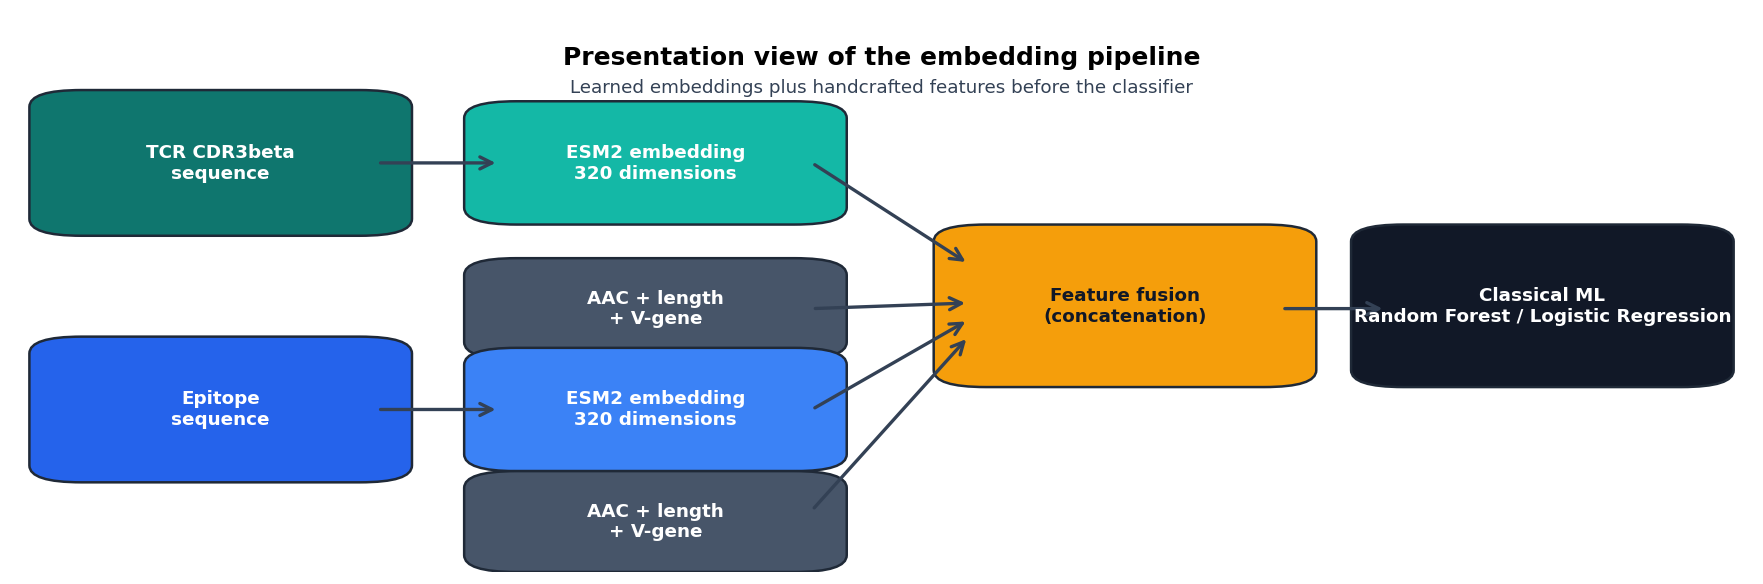

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def box(x, y, w, h, text, facecolor, textcolor="white", fontsize=11):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.03", linewidth=1.5, facecolor=facecolor, edgecolor="#1f2937")
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", color=textcolor, fontsize=fontsize, weight="bold")

def arrow(x1, y1, x2, y2, color="#334155"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=18, linewidth=2.0, color=color))

box(0.03, 0.62, 0.18, 0.22, "TCR CDR3beta\nsequence", "#0f766e")
box(0.03, 0.18, 0.18, 0.22, "Epitope\nsequence", "#2563eb")
box(0.28, 0.64, 0.18, 0.18, "ESM2 embedding\n320 dimensions", "#14b8a6")
box(0.28, 0.40, 0.18, 0.14, "AAC + length\n+ V-gene", "#475569")
box(0.28, 0.20, 0.18, 0.18, "ESM2 embedding\n320 dimensions", "#3b82f6")
box(0.28, 0.02, 0.18, 0.14, "AAC + length\n+ V-gene", "#475569")
arrow(0.21, 0.73, 0.28, 0.73)
arrow(0.21, 0.29, 0.28, 0.29)
box(0.55, 0.35, 0.18, 0.25, "Feature fusion\n(concatenation)", "#f59e0b", textcolor="#111827")
arrow(0.46, 0.73, 0.55, 0.55)
arrow(0.46, 0.29, 0.55, 0.45)
arrow(0.46, 0.47, 0.55, 0.48)
arrow(0.46, 0.11, 0.55, 0.42)
box(0.79, 0.35, 0.18, 0.25, "Classical ML\nRandom Forest / Logistic Regression", "#111827")
arrow(0.73, 0.47, 0.79, 0.47)
ax.text(0.5, 0.94, "Presentation view of the embedding pipeline", ha="center", va="top", fontsize=15, weight="bold")
ax.text(0.5, 0.88, "Learned embeddings plus handcrafted features before the classifier", ha="center", va="top", fontsize=11, color="#334155")
plt.tight_layout()
plt.show()

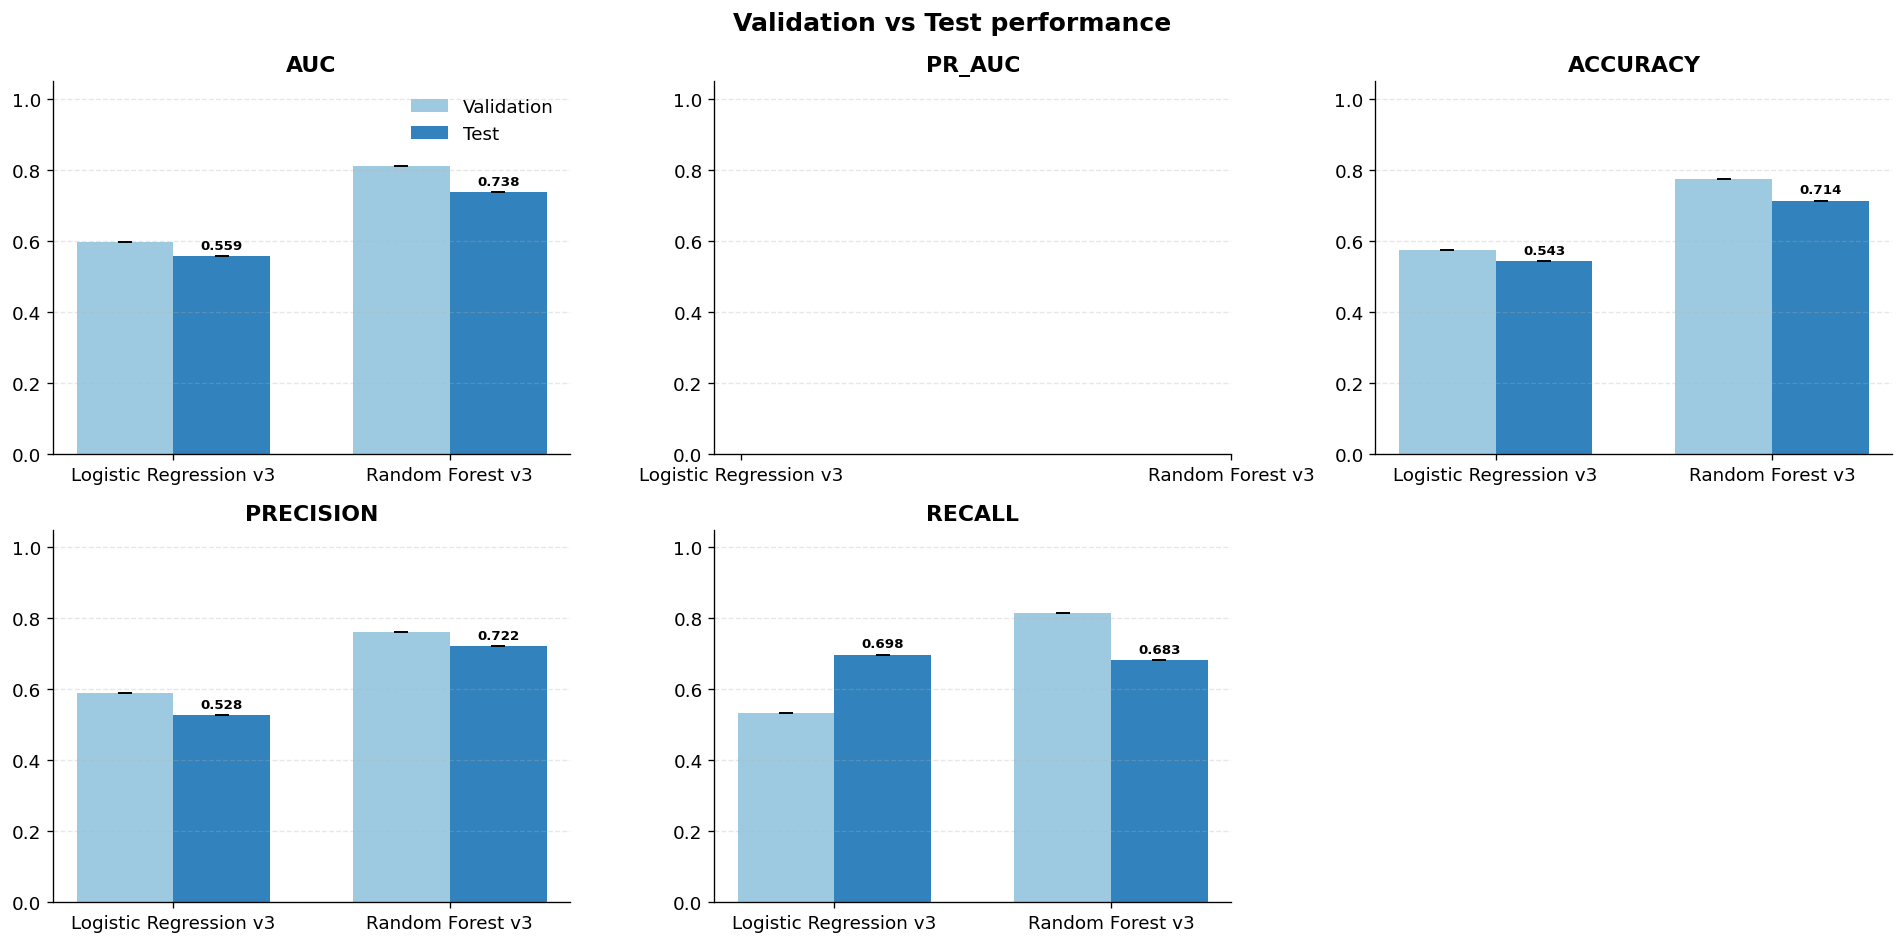

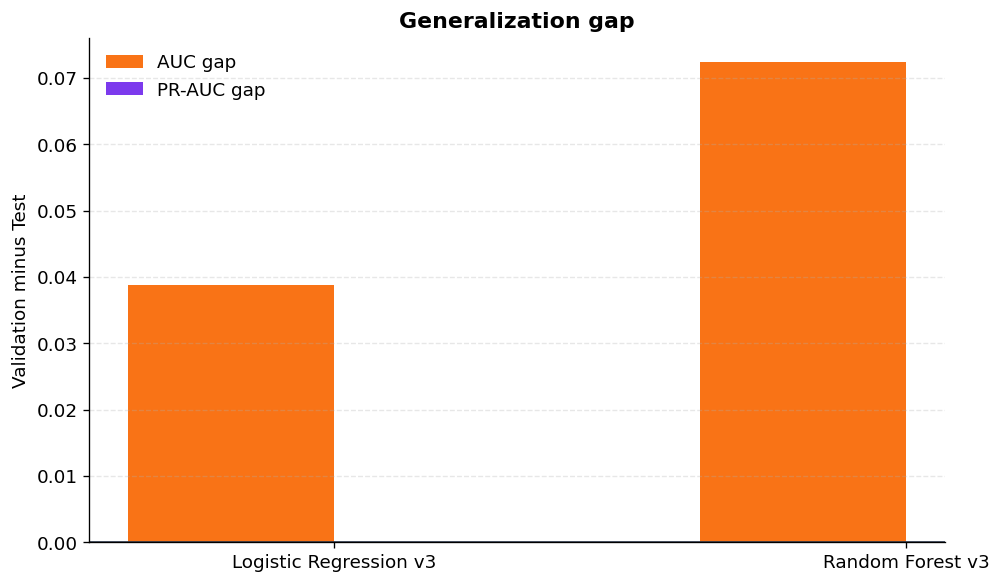

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
plot_metrics = ["auc", "pr_auc", "accuracy", "precision", "recall"]

for ax, metric in zip(axes, plot_metrics):
    x = np.arange(len(summary))
    width = 0.35
    val_means = summary[f"val_{metric}_mean"].to_numpy()
    val_stds = summary[f"val_{metric}_std"].to_numpy()
    test_means = summary[f"test_{metric}_mean"].to_numpy()
    test_stds = summary[f"test_{metric}_std"].to_numpy()

    ax.bar(x - width / 2, val_means, width, yerr=val_stds, capsize=4, color="#9ecae1", label="Validation")
    ax.bar(x + width / 2, test_means, width, yerr=test_stds, capsize=4, color="#3182bd", label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(summary["model"].tolist())
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.upper())
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    for idx, value in enumerate(test_means):
        if np.isfinite(value):
            ax.text(idx + width / 2, value + 0.012, f"{value:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[-1].axis("off")
axes[0].legend(frameon=False, loc="upper right")
fig.suptitle("Validation vs Test performance", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

gap = summary[["model", "auc_gap_mean", "pr_auc_gap_mean"]].copy()
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(gap))
ax.bar(x - 0.18, gap["auc_gap_mean"], 0.36, color="#f97316", label="AUC gap")
ax.bar(x + 0.18, gap["pr_auc_gap_mean"], 0.36, color="#7c3aed", label="PR-AUC gap")
ax.axhline(0, color="#334155", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(gap["model"].tolist())
ax.set_ylabel("Validation minus Test")
ax.set_title("Generalization gap")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

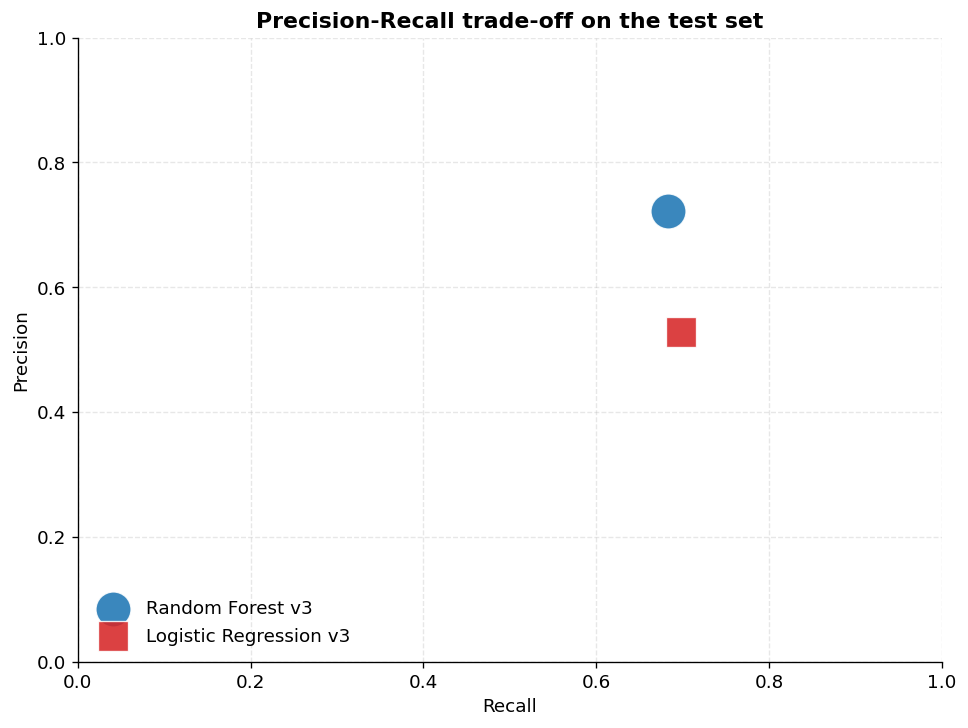

,Model,Runs,Test AUC,Test PR-AUC,Test Accuracy,Test Precision,Test Recall
1,Logistic Regression v3,1,0.559,nan,0.543,0.528,0.698
0,Random Forest v3,1,0.738,nan,0.714,0.722,0.683


In [9]:
fig, ax = plt.subplots(figsize=(8.2, 6.2))
for run_name in MODEL_NAMES:
    group = runs[runs["tags.mlflow.runName"] == run_name].copy()
    if group.empty:
        continue
    style = MODEL_STYLE[run_name]
    auc = pd.to_numeric(group["metrics.test_auc"], errors="coerce")
    precision = pd.to_numeric(group["metrics.test_precision"], errors="coerce")
    recall = pd.to_numeric(group["metrics.test_recall"], errors="coerce")
    sizes = 600 * np.clip(auc.fillna(0.5).to_numpy(), 0.15, 1.0)
    ax.scatter(
        recall,
        precision,
        s=sizes,
        color=style["color"],
        marker=style["marker"],
        alpha=0.88,
        edgecolor="white",
        linewidth=0.8,
        label=MODEL_LABELS[run_name],
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall trade-off on the test set")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

report = summary[["model", "n_runs", "test_auc_mean", "test_pr_auc_mean", "test_accuracy_mean", "test_precision_mean", "test_recall_mean"]].copy()
report.columns = ["Model", "Runs", "Test AUC", "Test PR-AUC", "Test Accuracy", "Test Precision", "Test Recall"]
display(report.style.format({
    "Test AUC": "{:.3f}",
    "Test PR-AUC": "{:.3f}",
    "Test Accuracy": "{:.3f}",
    "Test Precision": "{:.3f}",
    "Test Recall": "{:.3f}",
}))

## Slide-ready takeaways

- Random Forest v3 is the stronger classical baseline and clearly beats Logistic Regression v3.
- The embedding-based feature stack is already strong enough to justify the move to a GNN.
- ROC-AUC alone is not enough for the story; PR-AUC and the precision-recall plot are more informative for the presentation.
- The validation-to-test gap is the main argument for a more expressive model, not for more classical tuning.